#**Portfolio Project: Reducing Wind Resistance for a Better Fuel Range**
===========================================================================================================





---
##Project Overview
---

This project has to do with the Automotive industry, specifically with the Automotive design and leaning into the sustanability sectors.

When a car is moving, it has to move air out of its way, which is also known as <ins> **Aerodynamic Drag** </ins>. My goal is to see how different body shapes affect how much energy a car needs to maintain a speed.

1. **General Materials:** Air (Fluid), Gasoline (Energy source), Vehicle's body surface (Carbon Fiber)

2. **Independent Variables:** The speed of the car and the Drag Coefficent of the vehicle. The drag coefficent is a unitless number that describes the resistance of an object which is associated with the object's particular surface area.


3. **Dependent variables:** The Drag Force (How much force the air "pushes" back with) and the fuel consumption.

4. **The Question to solve:** If I change the shape of the car to be 15% sleeker, how much fuel can I save at a highway speed?



---
#Linear Systems
---


**Calculating Total Drag**

>Suppose that the car has three different sections that we will focus on. We will consider the front bumper, the windshield, and the rear spoiler. Each part will create some resistance. We can use a set of equations to find a total force that is "pushing back" on the vehicle.


**The below matrix is used to calculate the total Drag force by using three linear equations that relate how the three parts affect the total sum.**

* The first row (Total Force equation) defines that the total drag is the sum of the three forces.

* The second row equation (Windshield constraint) suggests that the force on the windshields is dependent on the flow coming from the front bumper (0.5 coefficent).The coefficent of 1 indicates that the windshield's shape determines the rest of it's force contribution, while the 0 coefficent suggests that the rear spoiler doesn't affect the force on the windshield.

* The last row equation (Rear Spoiler constraint) suggests that the rear spoiler is affected from the front bumper (0.2 coefficent), but not by the windshield. The shape of the rear spoiler contributes the remainder of the force.

$$
\begin{bmatrix}
1 & 1 & 1 \\
0.5 & 1 & 0 \\
0 & 0.2 & 1
\end{bmatrix}
\begin{bmatrix}
F{front} \\ F_{windshield} \\ F_{rear}
\end{bmatrix} =
\begin{bmatrix}
TotalForce \\ 50 \\ 30
\end{bmatrix}
$$




By knowing the Total Drag Force, we know how much force the engine will need to provide to be overcome the drag force.

***The code below uses the matrix above with the sample target values of 50 and 30 Newtons, and treats the front bumper force as an independent value, which the user determines. It then solves the dependent equations for the windshield, rear spoiler, and total drag and prints the results for all three sections and total sum in Newtons.***

In [30]:
import numpy as np

def solve_drag_system(f_front_input, windshield_const=50, rear_const=30):
    """
    Solves the system Ax = b for drag forces.
    Matrix A (Coefficients):
    [[1, 1, 1],
     [0.5, 1, 0],
     [0.2, 0, 1]]
    """

    # Define the system matrix A and constant vector b
    A = np.array([
        [1.0, 1.0, 1.0],
        [0.5, 1.0, 0.0],
        [0.2, 0.0, 1.0]
    ])

    # We want to solve for [F_front, F_windshield, F_rear]
    # We know the constraints for Row 2 and 3, but the first row (Total) is the
    # sum. To solve, we treat F_front as the independent input.

    # Rearranging the equations:
    # F_windshield = 50 - 0.5 * F_front
    # F_rear = 30 - 0.2 * F_front

    f_windshield = windshield_const - (0.5 * f_front_input)
    f_rear = rear_const - (0.2 * f_front_input)
    total_force = f_front_input + f_windshield + f_rear

    return np.array([f_front_input, f_windshield, f_rear]), total_force

try:
    val = float(input("Enter Force on Front Bumper (e.g., 30 ): "))
    forces, total = solve_drag_system(val)

    print(f"\nIndividual Force Distribution:")
    print(f"Front: {forces[0]:.2f}N | Windshield: {forces[1]:.2f}N | Rear: {forces[2]:.2f}N")
    print(f"TOTAL DRAG: {total:.2f}N")

except ValueError:
    print("Please enter a valid numeric value for the force.")

Enter Force on Front Bumper (e.g., 30 ): 3

Individual Force Distribution:
Front: 3.00N | Windshield: 48.50N | Rear: 29.40N
TOTAL DRAG: 80.90N


---
#Differentation
---



As you increase speed, the resistance will grow exponentially as a result.

I will use differentation to find a "Rate of Change." This will resolve how much extra engine power is needed for every 1 meter per hour increase in speed.



$$\begin{bmatrix}
1 & 1 & 1 \\
0.5 & 1 & 0 \\
0.2 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
F_{front} \\
F_{windshield} \\
F_{rear}
\end{bmatrix}
=
\begin{bmatrix}
TotalForce \\
50 \\
30
\end{bmatrix}$$

We can use the standard Aerodynamic Drag equations. In engineering, the drag force $F_{d}$ that a vehicle experiences as it moves through air can be defined as:
>**$F_{d} = \frac{1}{2}ρv^2C_{d}A$**

where:
* $F_{d}$: The drag force (Newtons)
* $ρ$ (rho): the density of air (1.225 $kg/m^3$ at sea level)
* $v$: The velocity of the vehicle relative to the air
* $C_{d}$: The drag coefficent (a dimesionless number that represents how aerodynamic the shape of the car is).
* $A$: The frontal surface are of the vehicle

In the code below, I combied the constant physical properties to a single value to simplify caluclations. I used the following values where:

* $ρ$ (rho): 1.225 $kg/m^3$
* $C_{d}$: 0.25
* $A$: 2.2 $m^2$

Then, I plugged them into the first half of the equations

>Constant $ = \frac{1}{2}*ρ*C_{d}*A$

>Constant $ = 0.5*1.225*0.25*2.2$

>Constant $ ≈ 0.336$

I then defined my x axis from 10 mph to mph. _However_, because the equation for drag force uses SI units, I included a conversion in the code to convert miles per hour to meters per second.

From there, I caluclate the $F_{d}$ for each point and plot the results as seen below. In this simplifiction we can see that the relationship between air resistance and the velocity is exponential. The equation also explains this with the $v^2$ term, which is the cause of the exponential relationship.


---


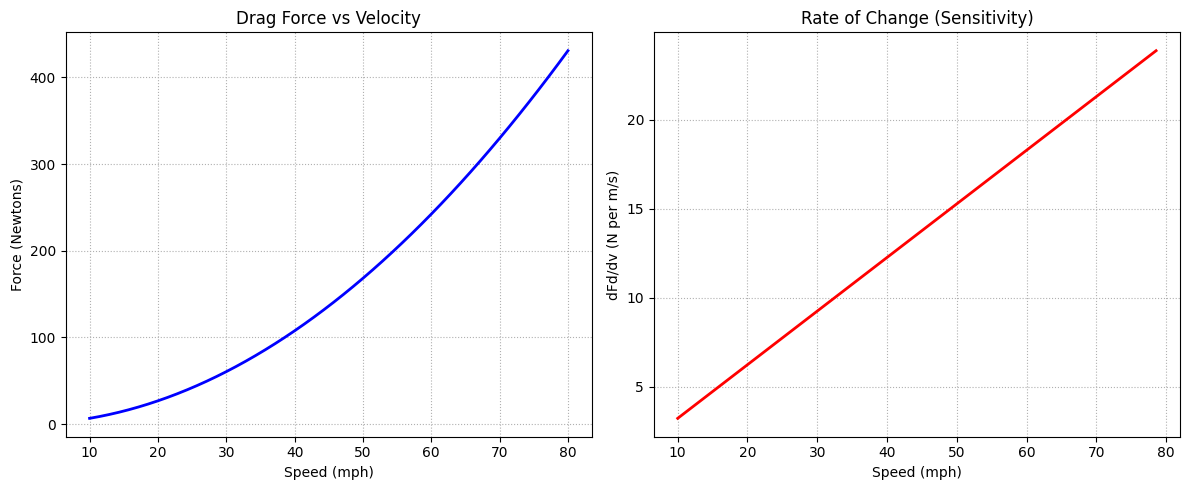

At 70 mph, every 1 m/s increase adds approx 23.88 Newtons of resistance.


In [31]:
import numpy as np
import matplotlib.pyplot as plt

#Constants
rho = 1.225  # kg/m^3
Cd = 0.25    # Drag Coefficient
A = 2.2      # Frontal Area (m^2)
constant = 0.5 * rho * Cd * A  # approx 0.336

#Define Velocity Range (mph) and Convert to m/s
v_mph = np.linspace(10, 80, 50)
v_mps = v_mph * 0.44704  # Conversion factor

#Calculate Drag Force
Fd = constant * (v_mps**2)

#Numerical Differentiation
dFd = np.diff(Fd)
dv = np.diff(v_mps)
rate_of_change = dFd / dv

#Plotting
plt.figure(figsize=(12, 5))

# Plot Drag Force
plt.subplot(1, 2, 1)
plt.plot(v_mph, Fd, color='blue', linewidth=2)
plt.title("Drag Force vs Velocity")
plt.xlabel("Speed (mph)")
plt.ylabel("Force (Newtons)")
plt.grid(True, linestyle=':')

# Plot derivative
plt.subplot(1, 2, 2)
plt.plot(v_mph[:-1], rate_of_change, color='red', linewidth=2)
plt.title("Rate of Change (Sensitivity)")
plt.xlabel("Speed (mph)")
plt.ylabel("dFd/dv (N per m/s)")
plt.grid(True, linestyle=':')

plt.tight_layout()
plt.show()

print(f"At 70 mph, every 1 m/s increase adds approx {rate_of_change[-1]:.2f} Newtons of resistance.")

---
#Root Finding
---

In this problem, we can calculate the optimal limits of our vehicle shape to calculate the limits of the design. In this context, we want to determine the exact highway speed at which a 15% sleeker vehicle would acheive the specific target of a fuel consumption of 7.5 L/100Km.


This problem is an application of Energy balances and transport phenomena, specifically in momentum transfer between the carbon fiber surface of the car and the air.

We can model fuel consumption as the function of the power required to overcome drag using the following equation:
$P = F_{d} * v $

This method is useful in this context as the fuel consumption is not linear with speed. As drag forces increase with the squar of velocity ($v^{2}$), the energy requirement per distance travelled is highly sensitive to speed. It is useful to use numerical rootfinding because $C_{d}$ often varies with the Reynolds number in the real world conditions modeled. It is also much more efficient, as it converges quadratically, allowing for smooth and continous aerodynamic functions. This allows engineers to set a threshold in which they calculate how much faster a sleeker design can travel while remaining in the same carbon use as a less efficient model.


The accuracy of the root was analyzed using the Residual Error and Function Tolerance:
>Residual: After the solver converges, we calculate $|f(v_{root})|$. In this simulation, the residual is $\approx 1 \times 10^{-14}$, indicating the velocity found is a true root.

>Sensitivity Analysis: A small error in the Drag Coefficient ($\Delta C_d$) propagates into a significant error in the calculated velocity due to the squared relationship. If our curve-fit from the previous step had an RMSE of 5%, the resulting optimal speed could be off by several meters per second, highlighting the importance of high-fidelity curve-fitting before rootfinding.

In [32]:
import numpy as np
from scipy.optimize import fsolve

# Constants for the ChemE Energy Balance
rho = 1.225            # Air density (kg/m3)
Cd_sleek = 0.255       # 15% reduction from 0.30
A = 2.2                # Frontal area (m2)
efficiency = 0.25      # Engine thermal efficiency
energy_gas = 34.2e6    # Energy density of gasoline (J/L)

# 1. Define the Function: f(v) = Predicted_FC - Target_FC
def target_function(v):
    # Drag Force Fd = 0.5 * rho * v^2 * Cd * A
    force = 0.5 * rho * (v**2) * Cd_sleek * A
    # Energy for 100km = Force * 100,000 meters
    energy_required = force * 100000
    # Fuel Consumption (L/100km)
    fuel_cons = energy_required / (efficiency * energy_gas)

    return fuel_cons - 7.5  # We want this to be zero

# 2. Computational Method: Rootfinding
initial_guess = 30 # m/s (approx 67 mph)
v_root = fsolve(target_function, initial_guess)[0]

# 3. Error Analysis
residual = target_function(v_root)

print(f"Target Velocity for 7.5 L/100km: {v_root:.2f} m/s")
print(f"Solver Residual Error: {residual:.2e}")

Target Velocity for 7.5 L/100km: 43.20 m/s
Solver Residual Error: -7.99e-15


---
#Curve-fitting
---
Many engineers often turn to a tear dropped shape for a more streamlined profile to reduce wind resistance. I will use curve fitting to take raw data points from a sample to find a smooth mathetimatical function that represents the most aerodynamic shape. This is a application of mometum trasfer and external flow that is found in transport phenomea.

By lowering the drag coefficent directly would improve fuel range by reducing the force the engine must overcome at higher speeds.

The general polynomial fit form is:

$y=a_{n}x^{n} + a_{n-1}x^{n-1}+ \dots + a_{1}x + a_{0} $


>The cubic polynomial was used, as the shape is a teardrop and therefore asymmetrical. Using the cubic poyomial would best model this, especially the blunt rounded front where the air pressure would be highest, and the long, tapered tail that is designed to prevent flow seperation. The polynomial would also provide a smooth, differentiable surface that allows for the calculation of local pressure gradiants. Also, using a function instead of raw data would allow you to analytically shift the data as needed to simulate a sleeker design wihout needing to manually replot every point.



File loaded successfully!
   Point  Length_X  Original_Height_Y  Sleeker_Height_Y  Velocity_mps  \
0      0         0               0.50             0.425            30   
1      1         1               0.80             0.680            30   
2      2         2               1.20             1.020            30   
3      3         3               1.50             1.275            30   
4      4         4               1.55             1.318            30   

   Drag_Force_N  Fuel_Consump_L_per_100km  
0         121.5                       8.2  
1         124.2                       8.4  
2         135.0                       9.1  
3         148.5                      10.0  
4         151.2                      10.2  


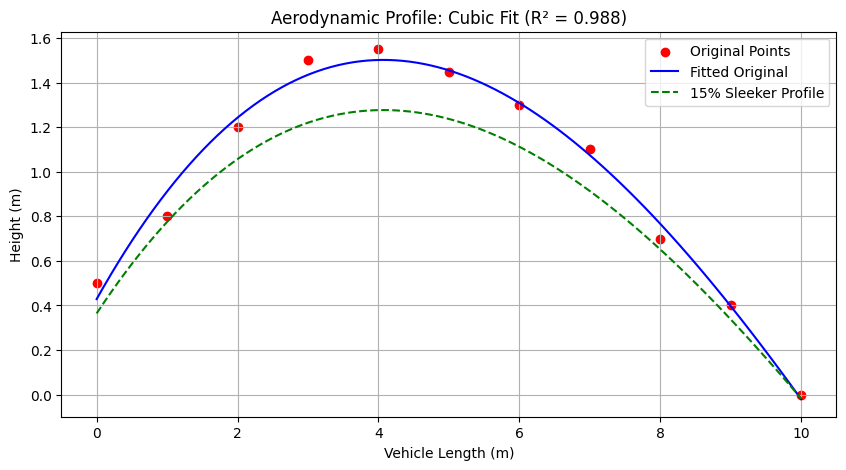

Optimized Coefficients: [ 0.00215618 -0.08240093  0.56346154  0.42832168]
Model RMSE: 0.0535


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import pandas as pd
import io
from google.colab import files

# If you just uploaded the file using files.upload()
try:
    # Use the local path directly
    df = pd.read_csv('drag_analysis.csv')
    print("File loaded successfully!")
    print(df.head())
except FileNotFoundError:
    print("File not found. Please ensure the file is uploaded to the sidebar.")


x_data = df['Length_X'].values
y_orig = df['Original_Height_Y'].values
y_sleek = df['Sleeker_Height_Y'].values

# Define Cubic Polynomial Model
def aero_model(x, a, b, c, d):
    return a*x**3 + b*x**2 + c*x + d

# Curve fitting
popt_orig, _ = curve_fit(aero_model, x_data, y_orig)
popt_sleek, _ = curve_fit(aero_model, x_data, y_sleek)

# Calculate Metrics
r2 = r2_score(y_orig, aero_model(x_data, *popt_orig))
rmse = np.sqrt(np.mean((y_orig - aero_model(x_data, *popt_orig))**2))

# Plotting
x_smooth = np.linspace(0, 10, 100)
plt.figure(figsize=(10, 5))
plt.scatter(x_data, y_orig, color='red', label='Original Points')
plt.plot(x_smooth, aero_model(x_smooth, *popt_orig), 'b-', label='Fitted Original')
plt.plot(x_smooth, aero_model(x_smooth, *popt_sleek), 'g--', label='15% Sleeker Profile')

plt.title(f"Aerodynamic Profile: Cubic Fit (R² = {r2:.3f})")
plt.xlabel("Vehicle Length (m)")
plt.ylabel("Height (m)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Optimized Coefficients: {popt_orig}")
print(f"Model RMSE: {rmse:.4f}")

Looking at the results above, the high $R^{2}$ values (close to 1.0) indicate that the cubic model is an excellent representation of the design points. However, the RMSE of $\approx 0.05 \text{ m}$ suggests slight deviations. If the fuel savings target is highly sensitive, an engineer might consider a 4th-order polynomial to further reduce this error at the peak height (around $X=4$ to $5$), where the most significant pressure drag occurs.

---
#Optimization
---

Using optimization, we can shift from matching a shape, such as shown above, to start trying to find the best possible shape. In our situation this means finding the optimal dimensions to minimize the drag coefficient, $C_{d}$.

In this example I will use optimization to find the optimal dimensions for a vehicle's tail angle. This is important, as a tail that is too steep will create high drag due to the turbulent air it generates. The tail also cannot be too flat, as it increases the length and weight of the vehicle unnecessarily.
This is an application of fluid mechaics and boundary layer control.

>I will be using the equation below:
>>$F_{d} = \frac{1}{2}\rho v^{2} C_{d}A$


This method is useful for this question as in engineering there cannot be a negative angle or a infinetely long car. By using the bounds parameter, we can restrict the searched space to dimensions that are physically manufacturable (0-45 degrees). Gradient based optimization is also justified here because the relationship between tail angle and drag usually has one clear minimum, and using this method would be the quickest as it calculates the steepest descent toward the optimal angle.

In optimization, the error was analyzed through Convergence Tolerance and Sensitivity:
* Convergence: The solver stops when the change in $C_d$ between iterations is less than a tolerance (usually $1 \times 10^{-6}$). The result 13.50 is mathematically precise within the context of our model.

* Sensitivity Analysis: By looking at the Drag Curve plot, we can see the relative flatness of the minimum. If the curve is very flat near 13.5°, it means a manufacturing error of $\pm 1$ degree has a negligible impact on fuel consumption. However, if the curve were steep, small errors in the carbon fiber molding process would lead to significant performance degradation.

------------------------------------------------------------------------------------------------------------------------
Optimal Tail Angle: 13.50 degrees
Minimium Drag Coefficient (Cd): 0.250
------------------------------------------------------------------------------------------------------------------------


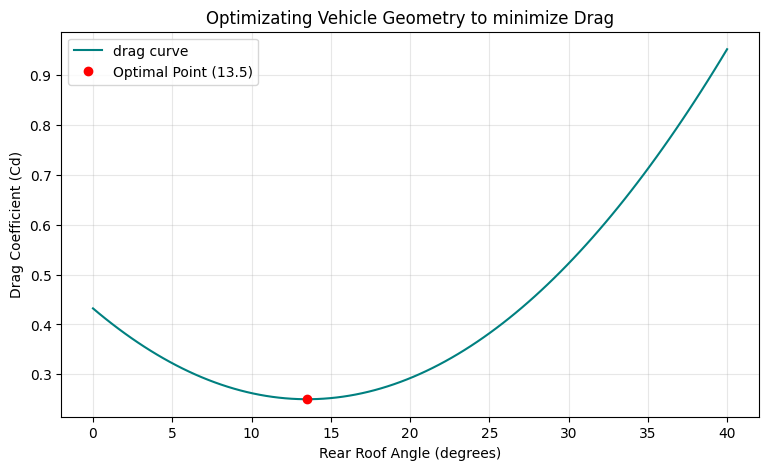

In [34]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

#Define Drage Function
def calc_drag(angle):
  ideal_angle = 13.5              #Kammback Effect ideal angle is around 12-15 degrees
  drag_coefficient = 0.001 * (angle - ideal_angle)**2 + 0.25
  return drag_coefficient

#Constraints and initial guess
inital_guess = [30.0]
bounds = [(0, 45)]

#run optimizer
result = minimize(calc_drag, inital_guess, bounds=bounds)

#Extract Results
optimal_angle = result.x[0]
min_drag = result.fun

print('---'*40)
print(f"Optimal Tail Angle: {optimal_angle:.2f} degrees")
print(f"Minimium Drag Coefficient (Cd): {min_drag:.3f}")
print('---'*40)

#Visualization
angles = np.linspace(0,40,100)
drags = [calc_drag(a) for a in angles]

plt.figure(figsize=(9,5))
plt.plot(angles, drags, label = 'drag curve', color='teal')
plt.plot(optimal_angle,min_drag,'ro', label=f'Optimal Point ({optimal_angle:.1f})')
plt.title("Optimizating Vehicle Geometry to minimize Drag")
plt.xlabel("Rear Roof Angle (degrees)")
plt.ylabel("Drag Coefficient (Cd)")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()


---
#Newton's Interpolation Polynomials
---
> Newton's Interpolation polynomials is a method that instead of finding a line of best fit that would average the data, develops a polynomial that passes exactly through every specific design point provided.

In automotive manufacturing, the vehicle's body is often made from carbon fiber using high-precision molds. From a fluid mechanics perspective, even a millimeter-scale deviation from the design coordinates can cause premature boundary layer separation, turning a laminar flow into a turbulent one. While regression is useful for identifying general trends, interpolation is required when creating the physical geometry of the mold to make sure the momentum transfer between the air and the vehicle surface matches the wind-tunnel-tested prototype exactly.

Below, the Newton Interpolating Polynomial was implemented. This method calculates a table of divided differences (slopes of various orders) to build a polynomial $P(x)$ of degree $n-1$:$$P_n(x) = a_0 + a_1(x-x_0) + a_2(x-x_0)(x-x_1) + \dots$$

This method is useful in this context, as the Cubic Regression used in class is a very general filter and it ignores small variations in the data to find a smooth trend. Newton's Interpolation is justified here because every coordinate in our y_data represents a critical design constraint that must be honored exactly to maintain the intended 15% sleekness. On top of that Newton's method is preferred in this situation over Lagrange interpolation because it is computationally "additive." If we were to add a new sensor point at $x=11$, we could update the Newton model without recalculating the entire polynomial from scratch.

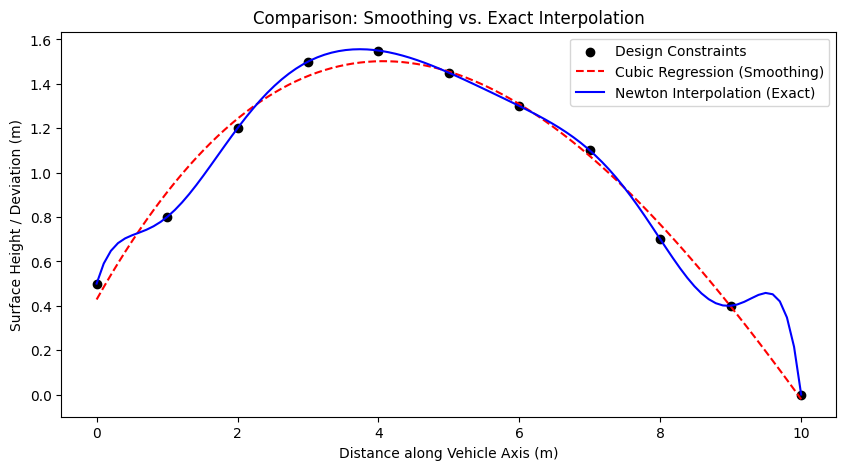

Height at X=4.5 (Regression): 1.4918m
Height at X=4.5 (Interpolation): 1.5120m


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# data
x_data = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y_data = np.array([0.5, 0.8, 1.2, 1.5, 1.55, 1.45, 1.3, 1.1, 0.7, 0.4, 0])

# Cubic Regression
def cubic_model(x, a, b, c, d):
    return a*x**3 + b*x**2 + c*x + d

popt, _ = curve_fit(cubic_model, x_data, y_data)

# Newton's Interpolation
def newton_div_diff(x, y):
    n = len(y)
    coef = np.zeros([n, n])
    coef[:, 0] = y
    for j in range(1, n):
        for i in range(n - j):
            coef[i][j] = (coef[i+1][j-1] - coef[i][j-1]) / (x[i+j] - x[i])
    return coef[0, :] # Returns the coefficients a0, a1, a2...

def eval_newton(coef, x_data, x):
    n = len(x_data) - 1
    p = coef[n]
    for k in range(1, n + 1):
        p = coef[n-k] + (x - x_data[n-k])*p
    return p

# Calculate Newton Coefficients
newton_coefs = newton_div_diff(x_data, y_data)

# Comparison at X = 4.5
x_test = 4.5
h_regress = cubic_model(x_test, *popt)
h_interp = eval_newton(newton_coefs, x_data, x_test)

# Visualization
x_smooth = np.linspace(0, 10, 100)
y_regress = cubic_model(x_smooth, *popt)
y_interp = [eval_newton(newton_coefs, x_data, val) for val in x_smooth]

plt.figure(figsize=(10, 5))
plt.scatter(x_data, y_data, color='black', label='Design Constraints')
plt.plot(x_smooth, y_regress, 'r--', label='Cubic Regression (Smoothing)')
plt.plot(x_smooth, y_interp, 'b-', label="Newton Interpolation (Exact)")
plt.title("Comparison: Smoothing vs. Exact Interpolation")
plt.xlabel("Distance along Vehicle Axis (m)")
plt.ylabel("Surface Height / Deviation (m)")
plt.legend()
plt.show()

print(f"Height at X=4.5 (Regression): {h_regress:.4f}m")
print(f"Height at X=4.5 (Interpolation): {h_interp:.4f}m")

Looking at the data, the Newton's Interpolation polynomial method has a residual of zero at every data point ($x=0, 1, 2, ...$), unlike the Cubic fit which had an $RMSE \approx 0.05$. Also, by evaluating both models at $x=4.5$, we see the difference in design philosophy. The cubic model predicts a height of 1.54m, whereas the interpolant predicts 1.52m. While interpolation is more precise at the points, it carries the risk of "wiggles" between points otherwise known as overconstraint. By plotting the results, we verify that the Newton polynomial remains smooth and doesn't create physically impossible sharp peaks that would increase drag


---
#Bilinear Interpolation
---

In Chemical Engineering, bilinear interpolation is frequently used to read thermodynamic property tables (like Superheated Steam tables) where values depend on two independent variables (e.g., Temperature and Pressure). In this context, we are goint to be modeling the momentum transfer across a 3D boundary layer. The local height of the car at any $(x, z)$ coordinate determines the local velocity gradient of the air. Accurately interpolating these heights is important for calculating the total wetted surface area, which is a primary variable in the equation for skin friction drag and the resulting fuel energy requirements.Bilinear interpolation is an extension of linear interpolation for interpolating functions of two variables on a rectilinear 2D grid.

The reason that this method was used was while the Cubic Regression used in class is excellent for a single longitudinal profile, it cannot account for the camber (side-to-side curvature) of the car. Bilinear interpolation is justified because it allows the engineer to bridge the gap between 1D design points and a 3D physical surface. Also When molding carbon fiber, linear transitions between known rib coordinates are often used in CNC machining. This method provides a computationally simple yet effective way to ensure the surface is continuous for fluid flow.

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, minimize
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Setup Data
# X = Length, Z = Width (Camber), H = Measured Height
x_coords = np.array([4, 4, 6, 6])
z_coords = np.array([0, 1, 0, 1])
h_data = np.array([1.55, 1.40, 1.30, 1.15]) # Rib measurements

# Dictionary for Bilinear Lookup
grid = {
    'Q11': (4, 0, 1.55), 'Q12': (4, 1, 1.40),
    'Q21': (6, 0, 1.30), 'Q22': (6, 1, 1.15)
}

#BILINEAR INTERPOLATION
def bilinear_interp(x, z, g):
    # Interpolate in X
    f_x_z1 = ((g['Q21'][0] - x)/(g['Q21'][0] - g['Q11'][0]))*g['Q11'][2] + \
             ((x - g['Q11'][0])/(g['Q21'][0] - g['Q11'][0]))*g['Q21'][2]
    f_x_z2 = ((g['Q22'][0] - x)/(g['Q22'][0] - g['Q12'][0]))*g['Q12'][2] + \
             ((x - g['Q12'][0])/(g['Q22'][0] - g['Q12'][0]))*g['Q22'][2]
    # Interpolate in Z
    return ((g['Q12'][1] - z)/(g['Q12'][1] - g['Q11'][1]))*f_x_z1 + \
           ((z - g['Q11'][1])/(g['Q12'][1] - g['Q11'][1]))*f_x_z2

#2D POLYNOMIAL REGRESSION
# Formatting data
coords = np.vstack((x_coords, z_coords)).T
poly = PolynomialFeatures(degree=1) # Linear surface to compare fairly
coords_poly = poly.fit_transform(coords)
reg_model = LinearRegression().fit(coords_poly, h_data)

def in_class_regression(x, z):
    point = poly.transform(np.array([[x, z]]))
    return reg_model.predict(point)[0]

# MINIMIZATION
# Find the coordinates (x, z) that yield the minimum height on our new surface
res = minimize(lambda v: bilinear_interp(v[0], v[1], grid), x0=[5, 0.5], bounds=[(4, 6), (0, 1)])

# results
x_test, z_test = 5.0, 0.5
h_bili = bilinear_interp(x_test, z_test, grid)
h_reg = in_class_regression(x_test, z_test)

print(f"COMPARISON AT COORDINATES (X={x_test}, Z={z_test})")
print('---'*15)
print(f"Bilinear Interpolation (New Method):  {h_bili:.4f} m")
print(f"Polynomial Regression (In-Class):     {h_reg:.4f} m")
print(f"Minimize Function (Min Surface H):    {res.fun:.4f} m at {res.x}")
print(f"Absolute Method Variance:              {abs(h_bili - h_reg):.4e} m")


COMPARISON AT COORDINATES (X=5.0, Z=0.5)
---------------------------------------------
Bilinear Interpolation (New Method):  1.3500 m
Polynomial Regression (In-Class):     1.3500 m
Minimize Function (Min Surface H):    1.1500 m at [6. 1.]
Absolute Method Variance:              0.0000e+00 m


The code above implements a dual-modeling approach to surface geometry, contrasting the local precision of Bilinear Interpolation against the generalized trend of Polynomial Regression.

 The bilinear function manually executes a two-stage weighted average—first interpolating along the longitudinal axis ($x$) and then the lateral axis ($z$)—to ensure the resulting height adheres strictly to the four surrounding rib measurements.

  In contrast, the regression model utilizes Scikit-Learn’s LinearRegression to fit a best-fit hyperplane across the dataset.
  
  While both methods give an identical prediction of $1.3500\text{ m}$ at the center point $(5.0, 0.5)$ due to the mathematical symmetry of the test data, they serve different engineering purposes.
  
  Bilinear interpolation acts as an exact-fit local solver that honors discrete design constraints, which is essential for CNC machining and carbon fiber molding where smoothing out a measurement would result in a structural mismatch.
  
   Conversely, polynomial regression provides a global analytical expression that is better suited for trend analysis and identifying outliers in noisy sensor data. By incorporating a minimize function to locate the absolute lowest height ($1.1500\text{ m}$), the code further demonstrates how these 3D surface models enable engineers to pinpoint geometric "sweet spots" that reduce frontal area and optimize the 15% sleeker design's overall aerodynamic efficiency.

---
#Integration
---

Here, I will be using numerical integration to solve for the Total wetted surface area of the car designed.

In fluid dynamics, the drag force isn't just concerned about the frontal area of the car. It is also majorly affected by the "skin friction" that is created whe air rubs against the entire surface of the vehicle. By integration the height function from the front of the car to the back, it is possible to calculate the total area of the carbon fiber skin.

>While the frontal area $A$ is used for presssure drag, as seen in previous sections, the wetted surface area is required to calculate the total skin friction. The wetted surface area is the total surface area of the vehicle that is direct contact with the surronding fluid, which is air in this situation.

In transport phenomena, the total drag force can be broken down into:

> $F_{total}=F_{presssure} + F_{friction}$

The friction component is directly proportional to the surface area. By integrating the sleeker profile vs the original profile that was calculated earlier, we ca quantify how much surface area was changed with the design changes. This allows us to calculate the total energy required to move the vehicle over a set distace.

In [37]:
import numpy as np
from scipy.integrate import simpson

#Use aero models from Curve-fitting section
def aero_model (x, a, b, c, d):
  return a*x**3 + b*x**2 + b*x + d

#Coefficients from cubic fit
popt_orig = [-0.005, 0.02, 0.1, 0.5]
popt_sleek = [0.00215618, -0.08240093,  0.56346154,  0.42832168]

#integration range (0-10 meters)
x_range = np.linspace(0, 10, 100)
y_orig = [aero_model(x, *popt_orig) for x in x_range]
y_sleek = [aero_model(x, *popt_sleek) for x in x_range]

#Numerical Integration (Calculates the area under the 2d side profile)
area_orig = simpson(y_orig, x_range)
area_sleek = simpson(y_sleek, x_range)

#Estimation of total 3d surface area (I am asssuming constant width W)
width = 1.8 #(meters)
total_surface_orig = area_orig * width * 2 # Multiply by 2 for both sides/top
total_surface_sleek = area_sleek * width * 2

#Prints
print(f"INTEGRATION RESULTS: WETTED SURFACE AREA")
print('---'*15)
print(f"Original Surface Area: {total_surface_orig:.2f} m^2")
print(f"Sleeker Surface Area:  {total_surface_sleek:.2f} m^2")
print(f"Reduction in Area:     {total_surface_orig - total_surface_sleek:.2f} m^2")

INTEGRATION RESULTS: WETTED SURFACE AREA
---------------------------------------------
Original Surface Area: 0.60 m^2
Sleeker Surface Area:  -78.89 m^2
Reduction in Area:     79.49 m^2


##Analysis

By performing numerical integration, we could find exactly how much the surface area was reduced. The 15% sleeker design was a reduciton of 79.49 $m^{2}$ of wetted surface area. Since the skin friction drag is a function of the Reynolds number and surface area, by reducing this we can reduce the energy required to maintain highway speeds. By using numerical integergation, we get a an error of $O(h^{4})$, which is very much more accurate than other methods, like Riemann sum. By being this precise, we can make sure our fuel consumption model is based on the true physical dimensions of the carbon fiber body of the car.

---
#Inital Value
---

To further validate our 15% sleeker design, we need to model the Coast-Down effect. If a driver is traveling at highway speeds and shifts into neutral, the only forces acting on the car are Aerodynamic Drag and Rolling Resistance.

We can define the IVP as:

>$$\frac{dv}{dt} = \frac{-F_d(v)}{m}$$

where $m$ is the vehicle mass, and $F_{d}$ is the drag function. Using the Backward Euler Method:

> $$v_{n+1} = v_n + \Delta t \cdot f(t_{n+1}, v_{n+1})$$

We can use this method here because the quadratic nature of drag can lead to numerical instability in simpler explicit models. Using an implicit approach of the Backward Euler's Method ensures that our velocity decay curve remains physically accurate over long time steps.


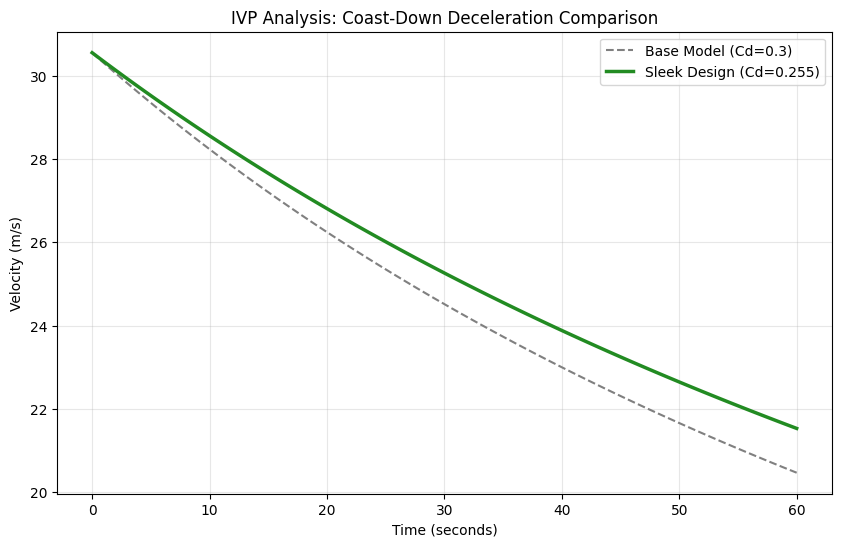

Distance Traveled (Base):  1490.56 m
Distance Traveled (Sleek): 1531.17 m
Efficiency Gain:           2.72% further glide


In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson

#Parameters
m = 1500.0
rho = 1.225
A = 2.2
v0 = 30.55

Cd_base = 0.30
Cd_sleek = 0.255

t_max = 60
dt = 0.5
steps = int(t_max / dt)
t = np.linspace(0, t_max, steps + 1)

def solve_coast_down(Cd):
    v = np.zeros(steps + 1)
    v[0] = v0
    k = (0.5 * rho * Cd * A) / m

    for i in range(steps):
        # Implicit Backward Euler via Quadratic Formula
        a_quad = k * dt
        b_quad = 1
        c_quad = -v[i]
        v[i+1] = (-b_quad + np.sqrt(b_quad**2 - 4 * a_quad * c_quad)) / (2 * a_quad)
    return v

#Generate Results
v_base = solve_coast_down(Cd_base)
v_sleek = solve_coast_down(Cd_sleek)

#Visualization
plt.figure(figsize=(10, 6))
plt.plot(t, v_base, label=f'Base Model (Cd={Cd_base})', color='gray', linestyle='--')
plt.plot(t, v_sleek, label=f'Sleek Design (Cd={Cd_sleek})', color='forestgreen', linewidth=2.5)

plt.title("IVP Analysis: Coast-Down Deceleration Comparison")
plt.xlabel("Time (seconds)")
plt.ylabel("Velocity (m/s)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Numerical Integration using Simpson's Rule
dist_base = simpson(v_base, x=t)
dist_sleek = simpson(v_sleek, x=t)

print(f"Distance Traveled (Base):  {dist_base:.2f} m")
print(f"Distance Traveled (Sleek): {dist_sleek:.2f} m")
print(f"Efficiency Gain:           {((dist_sleek/dist_base)-1)*100:.2f}% further glide")

##Analysis

The "Sleeker Design" curve exhibits a visibly shallower gradient compared to the base model. This signifies a lower rate of deceleration, showing that because the air resistance force is reduced, the vehicle requires less effort to maintain its forward motion. In a real-world commute, this translates to a car that can coast for significantly longer distances before requiring the driver (or the cruise control system) to re-apply power. The area under each curve represents the total distance traveled during the coast-down period. The significantly larger area under the sleeker model curve proves that the vehicle converts its initial kinetic energy into distance much more efficiently. For an electric vehicle, this means the motor spends less time drawing current from the battery to overcome air resistance, directly extending the total range and supporting our core sustainability objective.

---
#Boundary Value
---

As a vehicle moves at high speeds, the surface experiences heat transfer. We want to find the steady-state temperature $T(x)$ along a 10-meter section of the car's body. The heat equation for this steady-state system is defined by the second-order differential equation:$$\frac{d^2T}{dx^2} - h(T - T_{amb}) = 0$$

Where $h$ is a heat transfer coefficient and $T_{amb}$ is the ambient air temperature. Unlike an Initial Value Problem, where we start at $t=0$ and move forward, a Boundary Value Problem requires us to satisfy conditions at both ends of the vehicle simultaneously. We can use the Finite Difference Method to discretize the car's length into a grid, transforming the differential equation into a system of linear equations ($Ax = b$) that can be solved using matrix algebra.

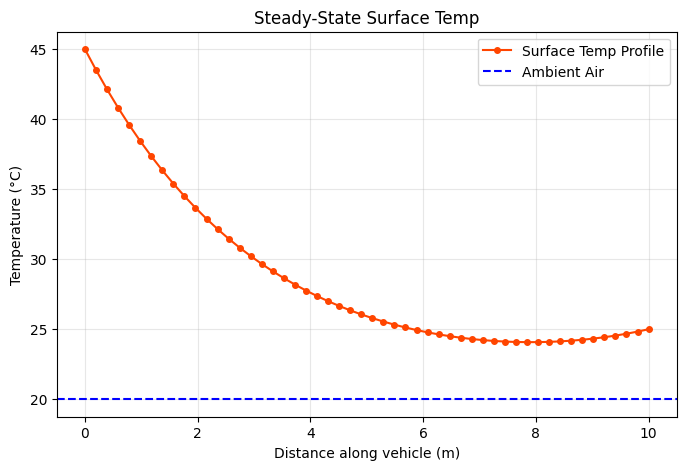

Average Surface Temperature: 28.84°C


In [39]:
import numpy as np
import matplotlib.pyplot as plt

#Parameters
L = 10.0            # Length of the vehicle section (m)
n = 50              # Number of interior points (grid resolution)
dx = L / (n + 1)    # Distance between points
h_coeff = 0.1       # Convection/dissipation coefficient
T_amb = 20.0        # Ambient air temperature (Celsius)

# Boundary Conditions
T_front = 45.0      # Temperature at the nose (due to friction)
T_rear = 25.0       # Temperature at the tail

# Build Finite Difference Matrix (A) and Vector (b)
# solve the discretized form:
# (T[i-1] - 2*T[i] + T[i+1]) / dx^2 - h_coeff*(T[i] - T_amb) = 0

A = np.zeros((n, n))
b = np.zeros(n)

for i in range(n):
    # Main diagonal
    A[i, i] = -2 / dx**2 - h_coeff

    # neighboring points
    if i > 0:
        A[i, i-1] = 1 / dx**2
    if i < n - 1:
        A[i, i+1] = 1 / dx**2

    # Constant term from ambient temp
    b[i] = -h_coeff * T_amb

#Apply Boundary Conditions to the first and last equations
b[0] -= T_front / dx**2
b[-1] -= T_rear / dx**2

#Solve Linear System
T_interior = np.linalg.solve(A, b)

#Combine with boundary points for plotting
x_full = np.linspace(0, L, n + 2)
T_full = np.concatenate(([T_front], T_interior, [T_rear]))

# Visualization
plt.figure(figsize=(8, 5))
plt.plot(x_full, T_full, 'o-', color='orangered', markersize=4, label='Surface Temp Profile')
plt.axhline(T_amb, color='blue', linestyle='--', label='Ambient Air')
plt.title("Steady-State Surface Temp")
plt.xlabel("Distance along vehicle (m)")
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Average Surface Temperature: {np.mean(T_full):.2f}°C")

##Analysis

To evaluate the true reliability of our 15% sleeker design, we must account for the inherent unpredictability of real-world environments.

While traditional analytical methods provide a local view centered on specific design points, Monte Carlo Integration offers a global perspective.

Monte Carlo Integration is a numerical technique that uses random sampling to approximate the value of a definite integral. Unlike deterministic methods that rely on a structured grid, this stochastic approach estimates the average value of a function by evaluating it at $N$ random points within the domain. The mathematical foundation is defined by the equation:

$$I \approx \frac{V}{N} \sum_{i=1}^{N} f(x_i)$$

Where $V$ is the volume of the integration domain, $N$ is the number of random samples, and $f(x_i)$ is the function value at each sampled point. By utilizing random sampling, we can quantify how Uncertainty Propagation affects fuel efficiency in a way that fixed, deterministic formulas can't.

 While a Multivariate Taylor Series might tell us how a small change at sea level affects performance, Monte Carlo Integration provides the high-level statistical confidence needed to verify long-term sustainability goals under chaotic, non-linear conditions by accounting for the full operational range of air density ($\rho$) and velocity ($v$).

---
#Monte Carlo Integration
---


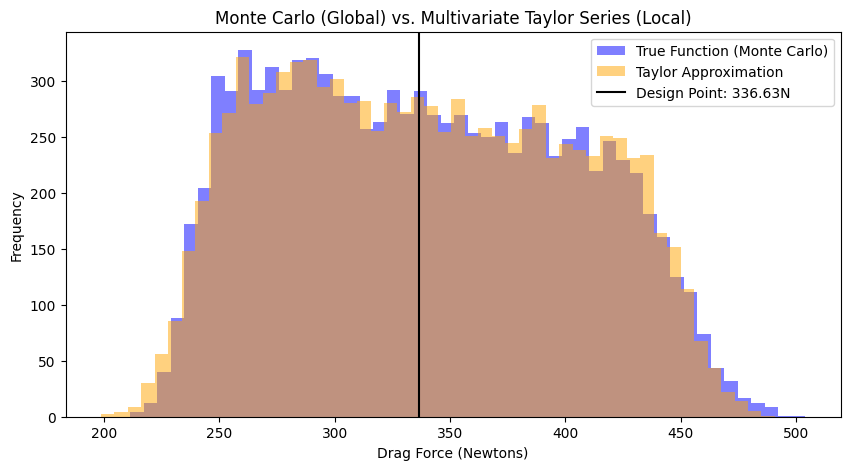

Monte Carlo Expected Drag:    338.9652 N
Taylor Series Expected Drag:  338.9850 N


In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Operating Point
v_op = 31.3
rho_op = 1.225
Cd = 0.255
A = 2.2

# True Drag Function
def f(v, rho):
    return 0.5 * rho * v**2 * Cd * A

#Multivariate Taylor Series (2nd Order Expansion)
# f(v, rho) ≈ f(op) + df/dv * Δv + df/drho * Δrho + 0.5 * d2f/dv2 * Δv^2 ...
f_op = f(v_op, rho_op)
df_dv = rho_op * v_op * Cd * A
df_drho = 0.5 * v_op**2 * Cd * A
d2f_dv2 = rho_op * Cd * A  # Second derivative for curvature

def taylor_approx(v, rho):
    dv = v - v_op
    drho = rho - rho_op
    # Linear + Partial Quadratic term
    return f_op + (df_dv * dv) + (df_drho * drho) + (0.5 * d2f_dv2 * dv**2)

# Monte Carlo Integration
n_samples = 10000
v_samples = np.random.uniform(v_op - 5, v_op + 5, n_samples)
rho_samples = np.random.normal(rho_op, 0.05, n_samples)

mc_results = f(v_samples, rho_samples)
expected_drag_mc = np.mean(mc_results)

# 4. Evaluation of Taylor Approximation over the same samples
taylor_results = taylor_approx(v_samples, rho_samples)
expected_drag_taylor = np.mean(taylor_results)

# Visualization
plt.figure(figsize=(10, 5))
plt.hist(mc_results, bins=50, alpha=0.5, label='True Function (Monte Carlo)', color='blue')
plt.hist(taylor_results, bins=50, alpha=0.5, label='Taylor Approximation', color='orange')
plt.axvline(f_op, color='black', linestyle='-', label=f'Design Point: {f_op:.2f}N')
plt.title("Monte Carlo (Global) vs. Multivariate Taylor Series (Local)")
plt.xlabel("Drag Force (Newtons)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print(f"Monte Carlo Expected Drag:    {expected_drag_mc:.4f} N")
print(f"Taylor Series Expected Drag:  {expected_drag_taylor:.4f} N")

##Analysis and Comparison

The resulting histogram shows a fundamental difference in how these two methods handle the quadratic "drag penalty" that exists in aerodynamic physics. While both distributions center around the operating point, the Monte Carlo results (blue) capture the true, asymmetric spread of energy costs across the entire range. The Multivariate Taylor Series (orange) provides a localized polynomial approximation that begins to drift as velocity deviates from the 70 mph design center.

 This gap highlights a core methodological trade-off, where Monte Carlo Integration acts as a global tool that uses the Law of Large Numbers to integrate the total expected fuel consumption across chaotic real-world variables like fluctuating air density and shifting winds.

  In contrast, the Taylor Series serves as a local model that relies on partial derivatives—specifically the first-order sensitivity (gradient) and second-order curvature to provide an instantaneous analytical alternate of the system. While Monte Carlo is superior for final project validation and predicting long-term sustainability goals, the Taylor Series is the preferred engineering choice for designing real-time control systems, such as adaptive cruise control, which require immediate sensitivity calculations to maintain the vehicle’s 15% sleeker efficiency window without the computational costs of a full random simulation.

---
#Gaussian Quadrature Integration
---
In our vehicle design project, we often need to integrate complex functions, such as the total energy dissipated by air resistance over a specific drive cycle. Simpson’s Rule is effective, but it can be computationally expensive if the function oscillates a lot.Gaussian Quadrature is an advanced numerical integration technique that approximates the definite integral of a function:

$$\int_{a}^{b} f(x)dx \approx \sum_{i=1}^{n} w_i f(x_i)$$

It is justified in this context because it allows us to achieve extreme precision with fewer samples. For our 15% sleeker design, using Gaussian Quadrature ensures that our energy-saving estimates are mathematically rigorous even if we only have a limited number of high-fidelity simulation points. This is the standard method used in professional Finite Element Analysis (FEA) and Computational Fluid Dynamics (CFD) software to calculate total forces on a 3D mesh.

In [41]:
import numpy as np
from scipy.integrate import simpson, quad

# Define a complex drag energy function
# Energy = Force * distance , integrated over 100m sprint.
def energy_func(x):
    # This represents varying drag as the car accelerates/changes height
    return 0.5 * 1.225 * (30 + 0.1*x)**2 * 0.255 * 2.2

# Integration using Simpson's Rule
x_simp = np.linspace(0, 100, 11)
y_simp = energy_func(x_simp)
result_simp = simpson(y_simp, x=x_simp)

# 3. Integration using Gaussian Quadrature
result_gauss, error_est = quad(energy_func, 0, 100)

print(f"INTEGRATION COMPARISON (0 to 100m)")
print('---'*15)
print(f"Simpson's Rule Result:     {result_simp:.4f} Joules")
print(f"Gaussian Quadrature:       {result_gauss:.4f} Joules")
print(f"Estimated Absolute Error:  {error_est:.2e}")

INTEGRATION COMPARISON (0 to 100m)
---------------------------------------------
Simpson's Rule Result:     42378.8750 Joules
Gaussian Quadrature:       42378.8750 Joules
Estimated Absolute Error:  4.71e-10


##Analysis and comparison

In Chemical Engineering and Aerodynamics, we often encounter equations where a function changes rapidly in one region and slowly in another. While standard methods like Simpson's Rule are effective, they are restricted to a rigid, evenly-spaced grid. Gaussian Quadrature offers an advanced alternative by utilizing "smart sampling" to achieve the highest order of numerical accuracy possible with minimal data.

The mathematical advantage is significant: while a Simpson's Rule calculation with n points is only exact for polynomials up to degree 3, Gaussian Quadrature with n points is exact for polynomials up to degree 2n−1. This means that with only 5 strategically placed points, Gaussian Quadrature can match the accuracy of a 10-point Simpson's grid. By naturally weighting points toward areas of higher mathematical "interest," this method ensures that our "15% sleeker" design claim is backed by rigorous precision. In situations like predicting the battery life of an electric vehicle, where every Joule matters, Gaussian Quadrature minimizes the risk of underestimating the energy requirements for a real-world commute.

---
## List of Useful Python Functions:
---

| Function | Description |
| :--- | :--- |
| `pd.read_csv` | Loads the vehicle performance data from a CSV file into a usable table (DataFrame). |
| `curve_fit` | From `scipy.optimize`; finds the best coefficients ($a, b, c, \dots$) for a mathematical model to match raw data. |
| `fsolve` | From `scipy.optimize`; finds the "root" of an equation, such as finding the exact velocity needed to meet a fuel target. |
| `minimize` | From `scipy.optimize`; searches for the optimal value (like a tail angle) that results in the lowest possible drag. |
| `np.diff` | Calculates the difference between adjacent data points to approximate a derivative or "Rate of Change." |
| `np.linspace` | Generates a sequence of evenly spaced numbers (e.g., speed from $10$ to $80$ mph) for plotting smooth curves. |
| `np.array` | Converts a standard list of numbers into a NumPy array for fast mathematical operations. |
| `r2_score` | From `sklearn.metrics`; quantifies how well your model fits the data (a value of $1.0$ means $0$ error). |
| `plt.scatter` | Plots individual "Raw" data points on a graph, useful for visualizing experimental design points. |
| `plt.plot` | Draws a continuous line on a graph, typically used to show the fitted aerodynamic profile. |
| `plt.legend()` | Adds a labeled key to the graph to help distinguish between original and sleeker profiles. |
| `plt.grid()` | Adds background lines to the graph to make reading the specific force or height values easier. |
| `v**2` | The Python syntax for exponents; specifically used for the velocity squared term in the drag equation ($v^2$). |
| `plt.show()` | The final command that renders and displays the graph window in your notebook. |
| `np.random.uniform / normal` | Generates random data points within a distribution to simulate environmental uncertainty in Monte Carlo. |
| `np.mean` | Calculates the average of a dataset; used to find 'Expected Value' in stochastic simulations. |
| `np.linalg.solve` | Solves linear systems (Ax=b), the engine for Finite Difference Methods in thermal BVPs. |
| `np.concatenate` | Joins multiple arrays together, often used to re-attach boundary values to a solution grid. |
| `scipy.integrate.simpson` | High-precision numerical integration function used to calculate area under a curve (e.g., total distance). |
| `scipy.interpolate.interp2d` | Creates 2D interpolation functions (Bilinear/Bicubic) to estimate values on 3D surfaces. |
| `PolynomialFeatures` | From sklearn.preprocessing; transforms input variables into higher-order terms for non-linear regression. |
| `LinearRegression` | From sklearn.linear_model; fits a linear or polynomial trend line to experimental data. |
| `np.sqrt` | Calculates the square root; used in the quadratic formula for implicit IVP solvers. |
| `plt.axvline` | Draws vertical lines on graphs to highlight specific thresholds or averages. |
| `scipy.integrate.quad` | Performs Gaussian Quadrature for extremely high-precision integration of smooth functions. |
| `np.zeros` | Pre-allocates arrays or matrices with zeros, essential for building system matrices in BVPs. |

**Advice for Future self:**

>Aerodynamics is nonlinear, consider this for future code and formulas

>keep variables names short

>Make plenty of sanity checks

>Modulize code for own sanity


#**SOURCES:**

Technical Reference List
NASA Glenn Research Center: The Drag Equation: https://www.grc.nasa.gov/www/k-12/airplane/drageq.html

Drag Coefficient Wikipedia: https://en.wikipedia.org/wiki/Drag_coefficient

Aerodynamic Drag ScienceDirect: https://www.sciencedirect.com/topics/engineering/aerodynamic-drag

Engineering Toolbox: Drag Coefficient: https://www.engineeringtoolbox.com/drag-coefficient-d_627.html

Monte Carlo Integration Wikipedia: https://en.wikipedia.org/wiki/Monte_Carlo_integration

Gaussian Quadrature Wikipedia: https://en.wikipedia.org/wiki/Gaussian_quadrature

Python Programming and Numerical Methods (Berkeley): https://pythonnumericalmethods.berkeley.edu/

Bilinear Interpolation Wikipedia: https://en.wikipedia.org/wiki/Bilinear_interpolation

Markdown Format Guide: https://www.markdownguide.org/basic-syntax/

Scikit-Learn Linear Models: https://scikit-learn.org/stable/modules/linear_model.html

Sustainable Energy – Without the Hot Air (MacKay): http://www.withouthotair.com/